In [9]:
feature_cols_lab = ["Median_Income", "House_Age", "Avg_Rooms", "Avg_Occupancy"]
X_lab = housing_df[feature_cols_lab]
y_lab = housing_df["Median_House_Value"]

In [10]:
X_train_lab, X_test_lab, y_train_lab, y_test_lab = train_test_split(
    X_lab, y_lab, test_size=0.20, random_state=42
)

print(f"Training Instances: {X_train_lab.shape[0]:,} | Holdout Test Instances: {X_test_lab.shape[0]:,}")

Training Instances: 16,512 | Holdout Test Instances: 4,128


In [11]:
lr_model_lab = LinearRegression()
lr_model_lab.fit(X_train_lab, y_train_lab)

LinearRegression()

In [13]:
y_test_pred_lab = lr_model_lab.predict(X_test_lab)

### TASK A: Regression Pipeline - Predicting Customer Lifetime Value (`Customer_LTV`)

In [2]:
import pandas as pd
import numpy as np

# Set a random seed for reproducibility
np.random.seed(42)

n_samples = 1000

# --- Numerical Features ---
monthly_contract_value = np.random.normal(loc=500, scale=150, size=n_samples).clip(100, 1500)
tenure_months = np.random.exponential(scale=24, size=n_samples).clip(1, 60)
user_seats = np.random.poisson(lam=5, size=n_samples).clip(1, 20)
support_escalations = np.random.poisson(lam=0.8, size=n_samples).clip(0, 5)
usage_growth_rate = np.random.normal(loc=0.05, scale=0.02, size=n_samples).clip(-0.05, 0.15)

# --- Categorical Features ---
industries = ['Tech', 'Healthcare', 'Finance', 'Education', 'Retail']
industry = np.random.choice(industries, size=n_samples, p=[0.3, 0.2, 0.2, 0.15, 0.15])

contract_plans = ['Basic', 'Standard', 'Premium', 'Enterprise']
contract_plan = np.random.choice(contract_plans, size=n_samples, p=[0.35, 0.3, 0.2, 0.15])

payment_frequencies = ['Monthly', 'Quarterly', 'Annually']
payment_frequency = np.random.choice(payment_frequencies, size=n_samples, p=[0.6, 0.25, 0.15])

onboarding_statuses = ['Completed', 'InProgress', 'Delayed']
onboarding_status = np.random.choice(onboarding_statuses, size=n_samples, p=[0.7, 0.2, 0.1])

# --- Target Variables ---
# Customer_LTV (regression target): influenced by contract value, tenure, user seats, usage growth
customer_ltv = (monthly_contract_value * tenure_months * (1 + usage_growth_rate)) \
               + (user_seats * 100) + np.random.normal(0, 500, n_samples)
customer_ltv = customer_ltv.clip(1000, 100000).round(2)

# Churn_Risk (classification target): influenced by support escalations, tenure, onboarding status
# Create a baseline churn probability
churn_prob = 1 / (1 + np.exp(-(0.1 * support_escalations \
                               + 0.05 * (60 - tenure_months) / 60 \
                               + (0.3 if onboarding_status[0] == 'Delayed' else 0)))) # Adjusted to avoid direct indexing issue
# Small adjustment for actual categorical values (simplified for generation)
churn_risk = (np.random.rand(n_samples) < churn_prob).astype(int)

# Ensure some churn cases for classification
# For simplicity, if churn_risk is too low, force some 1s.
if np.sum(churn_risk) < 0.1 * n_samples:
    num_to_force = int(0.1 * n_samples) - np.sum(churn_risk)
    indices_to_force = np.random.choice(np.where(churn_risk == 0)[0], num_to_force, replace=False)
    churn_risk[indices_to_force] = 1


# Create DataFrame
lab_df = pd.DataFrame({
    "Monthly_Contract_Value": monthly_contract_value,
    "Tenure_Months": tenure_months,
    "User_Seats": user_seats,
    "Support_Escalations": support_escalations,
    "Usage_Growth_Rate": usage_growth_rate,
    "Industry": industry,
    "Contract_Plan": contract_plan,
    "Payment_Frequency": payment_frequency,
    "Onboarding_Status": onboarding_status,
    "Customer_LTV": customer_ltv,
    "Churn_Risk": churn_risk
})

print(f"lab_df (synthetic) loaded successfully with shape: {lab_df.shape}")
print("First 5 rows of lab_df:")
display(lab_df.head())

lab_df (synthetic) loaded successfully with shape: (1000, 11)
First 5 rows of lab_df:


,Monthly_Contract_Value,Tenure_Months,User_Seats,Support_Escalations,Usage_Growth_Rate,Industry,Contract_Plan,Payment_Frequency,Onboarding_Status,Customer_LTV,Churn_Risk
0,574.507123,4.399227,2,1,0.030007,Tech,Enterprise,Monthly,Completed,3642.74,0
1,479.260355,2.650772,7,0,0.039685,Retail,Basic,Quarterly,Completed,1000.00,0
2,597.153281,24.282819,5,1,0.039513,Tech,Standard,Monthly,Completed,16006.46,0
3,728.454478,29.419079,5,0,0.098122,Retail,Basic,Monthly,Completed,24567.61,0
4,464.876994,1.000000,8,1,0.075102,Tech,Premium,Annually,Completed,1462.63,1


In [3]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge # Using Ridge as the regularized regression model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Assuming `lab_df` is available from CELL 0

# Segregate features into numerical and categorical groups (re-defining for self-containment if needed)
num_features = ["Monthly_Contract_Value", "Tenure_Months", "User_Seats", "Support_Escalations", "Usage_Growth_Rate"]
cat_features = ["Industry", "Contract_Plan", "Payment_Frequency", "Onboarding_Status"]

# 1. Numerical Preprocessing Sub-Pipeline: Median Imputation + Standard Scaling
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# 2. Categorical Preprocessing Sub-Pipeline: Mode Imputation + One-Hot Encoding
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# 3. Combine into unified ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_features),
        ("cat", cat_pipeline, cat_features)
    ],
    remainder="drop" # Drop unlisted columns (e.g., IDs)
)

# Define features (X) and target (y) for regression
X_reg = lab_df.drop(columns=["Customer_LTV", "Churn_Risk"])
y_reg = lab_df["Customer_LTV"]

# Split data into training and test sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

# Build the full regression pipeline (preprocessor + Ridge model)
regression_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0, random_state=42)) # Using Ridge with default alpha=1.0
])

# 3. Evaluate using 5-Fold Cross-Validation (report CV Mean R² ± Std)
cv_r2_scores = cross_val_score(regression_pipeline, X_train_reg, y_train_reg, cv=5, scoring="r2")

print(f"Regression 5-Fold CV R² Scores: {cv_r2_scores.round(4)}")
print(f"Mean CV R² Score:   {cv_r2_scores.mean():.4f} ± {cv_r2_scores.std():.4f}")

Regression 5-Fold CV R² Scores: [0.935  0.9068 0.9189 0.9234 0.937 ]
Mean CV R² Score:   0.9242 ± 0.0111


In [4]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 4. Evaluate on holdout test set (report RMSE, MAE, R²)
regression_pipeline.fit(X_train_reg, y_train_reg)
y_pred_reg = regression_pipeline.predict(X_test_reg)

reg_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
reg_mae = mean_absolute_error(y_test_reg, y_pred_reg)
reg_r2 = r2_score(y_test_reg, y_pred_reg)

print("\n=== Regression Holdout Test Metrics ===")
print(f"RMSE:        ${reg_rmse:,.2f}")
print(f"MAE:         ${reg_mae:,.2f}")
print(f"R² Score:    {reg_r2:.4f}")


=== Regression Holdout Test Metrics ===
RMSE:        $2,753.37
MAE:         $1,842.43
R² Score:    0.9295


In [5]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Define features (X) and target (y) for classification
X_clf = lab_df.drop(columns=["Customer_LTV", "Churn_Risk"])
y_clf = lab_df["Churn_Risk"]

# Split data into training and test sets with stratification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)

# Build the full classification pipeline (preprocessor + balanced LogisticRegression)
# 'preprocessor' is assumed to be defined in a previous cell (Cell 2226f48c)
classification_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# 3. Evaluate using 5-Fold Stratified Cross-Validation (report CV Mean ROC-AUC)
strat_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_roc_auc_scores = cross_val_score(classification_pipeline, X_train_clf, y_train_clf, cv=strat_kf, scoring="roc_auc")

print(f"Classification 5-Fold Stratified CV ROC-AUC Scores: {cv_roc_auc_scores.round(4)}")
print(f"Mean CV ROC-AUC Score:   {cv_roc_auc_scores.mean():.4f} ± {cv_roc_auc_scores.std():.4f}")

Classification 5-Fold Stratified CV ROC-AUC Scores: [0.5236 0.4966 0.5068 0.5331 0.6038]
Mean CV ROC-AUC Score:   0.5328 ± 0.0377


### TASK B: Classification Pipeline - Predicting Churn Risk (`Churn_Risk`)

In [6]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, classification_report, recall_score

In [7]:
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, classification_report, recall_score

# 4. Predict on holdout test set, optimize probability threshold to maximize F1/Recall,
#    and print the classification report & ROC-AUC.

classification_pipeline.fit(X_train_clf, y_train_clf)
probs_clf = classification_pipeline.predict_proba(X_test_clf)[:, 1]

optimal_f1_score = -1
optimal_threshold_clf = 0.5 # Default

# Iterate through possible thresholds
thresholds = np.linspace(0.01, 0.99, 100) # Check 100 thresholds

for thres in thresholds:
    y_pred_candidate = (probs_clf >= thres).astype(int)
    current_recall = recall_score(y_test_clf, y_pred_candidate, zero_division=0)
    current_f1 = f1_score(y_test_clf, y_pred_candidate, zero_division=0)

    # Prioritize recall >= 0.85, then maximize F1
    if current_recall >= 0.85:
        if current_f1 > optimal_f1_score:
            optimal_f1_score = current_f1
            optimal_threshold_clf = thres

y_pred_optimized = (probs_clf >= optimal_threshold_clf).astype(int)

print(f"\nOptimal Classification Threshold (for Recall >= 0.85, max F1): {optimal_threshold_clf:.2f}")
print(f"Achieved F1-Score at optimal threshold: {optimal_f1_score:.4f}")

print("\n=== Classification Report at Optimal Threshold ===")
print(classification_report(y_test_clf, y_pred_optimized, zero_division=0))

test_roc_auc = roc_auc_score(y_test_clf, probs_clf)
print(f"ROC-AUC on Holdout Test Set: {test_roc_auc:.4f}")


Optimal Classification Threshold (for Recall >= 0.85, max F1): 0.29
Achieved F1-Score at optimal threshold: 0.6508

=== Classification Report at Optimal Threshold ===
              precision    recall  f1-score   support

           0       1.00      0.01      0.02       104
           1       0.48      1.00      0.65        96

    accuracy                           0.48       200
   macro avg       0.74      0.50      0.33       200
weighted avg       0.75      0.48      0.32       200

ROC-AUC on Holdout Test Set: 0.5074


In [18]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, precision_score, classification_report

# --- START: Re-generation of df_fraud (to ensure it's always available) ---
# This block is duplicated from CELL 0 to ensure self-contained execution
np.random.seed(42)
n_samples = 5000
n_fraud = 150  # 3% minority class

# Legitimate transactions
amount_legit = np.random.exponential(scale=65, size=n_samples - n_fraud).clip(5, 1200)
freq_legit = np.random.poisson(lam=3, size=n_samples - n_fraud)
foreign_legit = np.random.binomial(n=1, p=0.05, size=n_samples - n_fraud)
risk_score_legit = np.random.normal(loc=25, scale=12, size=n_samples - n_fraud).clip(0, 100)
labels_legit = np.zeros(n_samples - n_fraud, dtype=int)

# Fraudulent transactions
amount_fraud = np.random.normal(loc=650, scale=250, size=n_fraud).clip(50, 2500)
freq_fraud = np.random.poisson(lam=8, size=n_fraud)
foreign_fraud = np.random.binomial(n=1, p=0.60, size=n_fraud)
risk_score_fraud = np.random.normal(loc=78, scale=15, size=n_fraud).clip(0, 100)
labels_fraud = np.ones(n_fraud, dtype=int)

# Combine and shuffle
df_fraud = pd.DataFrame({
    "Transaction_Amount": np.concatenate([amount_legit, amount_fraud]),
    "Daily_Tx_Frequency": np.concatenate([freq_legit, freq_fraud]),
    "Is_Foreign_Transaction": np.concatenate([foreign_legit, foreign_fraud]),
    "Risk_Score": np.concatenate([risk_score_legit, risk_score_fraud]),
    "Is_Fraud": np.concatenate([labels_legit, labels_fraud])
}).sample(frac=1.0, random_state=42).reset_index(drop=True)
# --- END: Re-generation of df_fraud ---


# 1. Define features (X) and target (y)
X_lab_grad = df_fraud[["Transaction_Amount", "Daily_Tx_Frequency", "Is_Foreign_Transaction", "Risk_Score"]]
y_lab_grad = df_fraud["Is_Fraud"]

# 1. Split the dataset (75% train, 25% test, stratify=y, random_state=101)
X_train_lab_grad, X_test_lab_grad, y_train_lab_grad, y_test_lab_grad = train_test_split(
    X_lab_grad, y_lab_grad, test_size=0.25, random_state=101, stratify=y_lab_grad
)

print(f"Graded Lab Training Instances: {X_train_lab_grad.shape[0]:,} | Graded Lab Test Instances: {X_test_lab_grad.shape[0]:,}")

Graded Lab Training Instances: 3,750 | Graded Lab Test Instances: 1,250


In [19]:
# 2. Train a LogisticRegression model with class_weight='balanced'
balanced_clf_grad = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=101)
balanced_clf_grad.fit(X_train_lab_grad, y_train_lab_grad)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=101)

In [20]:
# 3. Predict probabilities on test data
probs_test_grad = balanced_clf_grad.predict_proba(X_test_lab_grad)[:, 1]

# Find the optimal threshold for Recall >= 85% with highest Precision
optimal_threshold = 0.0
max_precision_at_recall = 0.0

# Iterate candidate thresholds between 0.10 and 0.90
thresholds = np.linspace(0.10, 0.90, 100) # Check 100 thresholds

for thres in thresholds:
    y_pred_candidate = (probs_test_grad >= thres).astype(int)
    current_recall = recall_score(y_test_lab_grad, y_pred_candidate, zero_division=0)
    current_precision = precision_score(y_test_lab_grad, y_pred_candidate, zero_division=0)

    if current_recall >= 0.85:
        if current_precision > max_precision_at_recall:
            max_precision_at_recall = current_precision
            optimal_threshold = thres

print(f"Optimal Threshold for Recall >= 85%: {optimal_threshold:.2f}")
print(f"Max Precision at this threshold: {max_precision_at_recall:.2f}")

y_pred_optimal = (probs_test_grad >= optimal_threshold).astype(int)

Optimal Threshold for Recall >= 85%: 0.46
Max Precision at this threshold: 0.97


In [21]:
# 4. Generate the full classification_report at this optimal threshold
print("\n=== CLASSIFICATION REPORT at Optimal Threshold ===")
print(classification_report(y_test_lab_grad, y_pred_optimal, zero_division=0))


=== CLASSIFICATION REPORT at Optimal Threshold ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1212
           1       0.97      1.00      0.99        38

    accuracy                           1.00      1250
   macro avg       0.99      1.00      0.99      1250
weighted avg       1.00      1.00      1.00      1250



In [6]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Re-define housing_df for self-contained execution
california = fetch_california_housing(as_frame=True)
housing_df = california.frame

# Debug: Print head to check if housing_df is created
print("Debugging housing_df creation (Cell 0642c098):")
print(housing_df.head(2))

housing_df = housing_df.rename(columns={
    "MedInc": "Median_Income",
    "HouseAge": "House_Age",
    "AveRooms": "Avg_Rooms",
    "AveBedrms": "Avg_Bedrooms",
    "Population": "Population",
    "AveOccup": "Avg_Occupancy",
    "Latitude": "Latitude",
    "Longitude": "Longitude",
    "MedHouseVal": "Median_House_Value"  # Target variable in $100,000s
})

feature_cols_lab = ["Median_Income", "House_Age", "Avg_Rooms", "Avg_Occupancy"]
X_lab = housing_df[feature_cols_lab]
y_lab = housing_df["Median_House_Value"]

X_train_lab, X_test_lab, y_train_lab, y_test_lab = train_test_split(
    X_lab, y_lab, test_size=0.20, random_state=42
)

lr_model_lab = LinearRegression()
lr_model_lab.fit(X_train_lab, y_train_lab)

y_test_pred_lab = lr_model_lab.predict(X_test_lab)

n_test_lab = len(y_test_lab)
p_features_lab = X_test_lab.shape[1]

mae_lab = mean_absolute_error(y_test_lab, y_test_pred_lab)
mse_lab = mean_squared_error(y_test_lab, y_test_pred_lab)
rmse_lab = np.sqrt(mse_lab)
r2_lab = r2_score(y_test_lab, y_test_pred_lab)

print("\n=== LAB HOLDOUT TEST EVALUATION METRICS ===")
print(f"MAE:         ${mae_lab * 100_000:,.2f}  (in actual USD)")
print(f"MSE:         {mse_lab:.4f}")
print(f"RMSE:        ${rmse_lab * 100_000:,.2f}  (in actual USD)")
print(f"R² Score:    {r2_lab:.4f}  ({r2_lab*100:.2f}% variance explained)")

Debugging housing_df creation (Cell 0642c098):
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127    1.02381       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137    0.97188      2401.0  2.109842     37.86   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  

=== LAB HOLDOUT TEST EVALUATION METRICS ===
MAE:         $60,254.80  (in actual USD)
MSE:         0.6575
RMSE:        $81,083.40  (in actual USD)
R² Score:    0.4983  (49.83% variance explained)


Debugging housing_df creation (Cell cd23b486):
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127    1.02381       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137    0.97188      2401.0  2.109842     37.86   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  


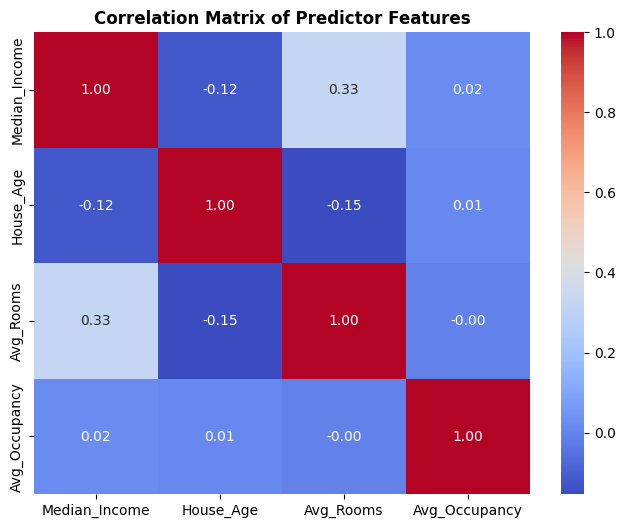


=== MULTICOLLINEARITY CHECK ===
The correlation matrix above shows the pairwise correlation between the selected features.
High absolute correlation values (e.g., > 0.7 or 0.8) indicate potential multicollinearity, which can affect the stability and interpretability of regression coefficients.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Re-define housing_df for self-contained execution
california = fetch_california_housing(as_frame=True)
housing_df = california.frame

# Debug: Print head to check if housing_df is created
print("Debugging housing_df creation (Cell cd23b486):")
print(housing_df.head(2))

housing_df = housing_df.rename(columns={
    "MedInc": "Median_Income",
    "HouseAge": "House_Age",
    "AveRooms": "Avg_Rooms",
    "AveBedrms": "Avg_Bedrooms",
    "Population": "Population",
    "AveOccup": "Avg_Occupancy",
    "Latitude": "Latitude",
    "Longitude": "Longitude",
    "MedHouseVal": "Median_House_Value"  # Target variable in $100,000s
})

feature_cols_lab = ["Median_Income", "House_Age", "Avg_Rooms", "Avg_Occupancy"]
X_lab = housing_df[feature_cols_lab]

correlation_matrix = X_lab.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Predictor Features", fontweight="bold")
plt.show()

print("\n=== MULTICOLLINEARITY CHECK ===")
print("The correlation matrix above shows the pairwise correlation between the selected features.")
print("High absolute correlation values (e.g., > 0.7 or 0.8) indicate potential multicollinearity, which can affect the stability and interpretability of regression coefficients.")